# Seismic Risk MLOps

## Notebook 01 — USGS Earthquake Data Exploration

### Objective

This notebook explores historical earthquake data obtained from the
United States Geological Survey (USGS).

We will analyze:

- Earthquake magnitude
- Earthquake depth
- Geographic distribution
- Temporal distribution
- Relationships between seismic variables
- Potential features for seismic-risk modeling

The results of this exploratory analysis will guide the feature engineering
and machine-learning stages of the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
DATA_FILE = "data/usgs_clean_2026.csv"

df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully.")
print(f"Number of earthquakes: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")

df.head()

Dataset loaded successfully.
Number of earthquakes: 19,527
Number of columns: 15


,id,time,magnitude,place,longitude,latitude,depth,type,datetime,year,month,day,hour,day_of_week,is_shallow
0,aka2026rmibwz,1788477690801,3.4,"57 km W of Anchor Point, Alaska",-152.8600,59.7750,112.1000,earthquake,2026-09-03 23:21:30.801000+00:00,2026,9,3,23,3,0
1,us7000te7g,1788477160776,3.0,"100 km SSW of Nikolski, Alaska",-169.2724,52.0704,10.0000,earthquake,2026-09-03 23:12:40.776000+00:00,2026,9,3,23,3,1
2,tx2026rjmsif,1788476520297,2.5,"57 km S of Whites City, New Mexico",-104.3870,31.6560,6.0999,earthquake,2026-09-03 23:02:00.297000+00:00,2026,9,3,23,3,1
3,us7000te7e,1788476059512,3.3,"98 km SSW of Nikolski, Alaska",-169.2923,52.0907,10.0000,earthquake,2026-09-03 22:54:19.512000+00:00,2026,9,3,22,3,1
4,us7000te7d,1788475335895,3.3,"88 km SSW of Nikolski, Alaska",-169.2418,52.1742,10.0000,earthquake,2026-09-03 22:42:15.895000+00:00,2026,9,3,22,3,1


In [4]:
print("Dataset shape:")
print(df.shape)

print("\nColumns:")
for column in df.columns:
    print("-", column)

print("\nData types:")
print(df.dtypes)

Dataset shape:
(19527, 15)

Columns:
- id
- time
- magnitude
- place
- longitude
- latitude
- depth
- type
- datetime
- year
- month
- day
- hour
- day_of_week
- is_shallow

Data types:
id                 str
time             int64
magnitude      float64
place              str
longitude      float64
latitude       float64
depth          float64
type               str
datetime           str
year             int64
month            int64
day              int64
hour             int64
day_of_week      int64
is_shallow       int64
dtype: object


In [5]:
print("Missing values by column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate earthquake IDs:")
print(df["id"].duplicated().sum())

Missing values by column:
id             0
time           0
magnitude      0
place          0
longitude      0
latitude       0
depth          0
type           0
datetime       0
year           0
month          0
day            0
hour           0
day_of_week    0
is_shallow     0
dtype: int64

Total missing values:
0

Duplicate earthquake IDs:
0


In [6]:
print("Magnitude statistics:")
print(df["magnitude"].describe())

print("\nDepth statistics (km):")
print(df["depth"].describe())

Magnitude statistics:
count    19527.000000
mean         3.816232
std          0.876615
min          2.500000
25%          2.900000
50%          4.100000
75%          4.500000
max          7.800000
Name: magnitude, dtype: float64

Depth statistics (km):
count    19527.000000
mean        56.613528
std        103.213023
min         -3.410000
25%         10.000000
50%         16.700000
75%         54.752500
max        683.578000
Name: depth, dtype: float64


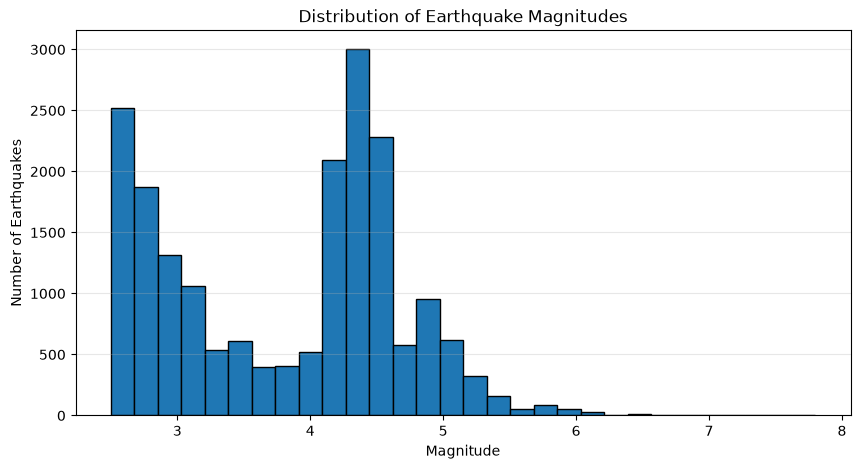

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(df["magnitude"], bins=30, edgecolor="black")

plt.title("Distribution of Earthquake Magnitudes")
plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")

plt.grid(axis="y", alpha=0.3)
plt.show()

In [8]:
magnitude_categories = pd.cut(
    df["magnitude"],
    bins=[0, 3, 4, 5, 6, 10],
    labels=[
        "Below 3",
        "3 to <4",
        "4 to <5",
        "5 to <6",
        "6 and above"
    ],
    right=False
)

category_counts = magnitude_categories.value_counts().sort_index()

print("Earthquakes by magnitude category:")
print(category_counts)

print("\nPercentage by category:")
print((category_counts / len(df) * 100).round(2))

Earthquakes by magnitude category:
magnitude
Below 3        5222
3 to <4        3545
4 to <5        9400
5 to <6        1262
6 and above      98
Name: count, dtype: int64

Percentage by category:
magnitude
Below 3        26.74
3 to <4        18.15
4 to <5        48.14
5 to <6         6.46
6 and above     0.50
Name: count, dtype: float64


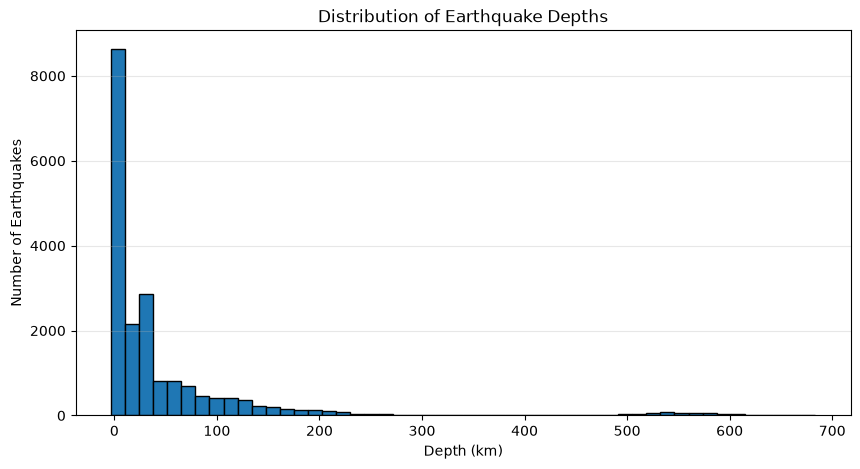

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(df["depth"], bins=50, edgecolor="black")

plt.title("Distribution of Earthquake Depths")
plt.xlabel("Depth (km)")
plt.ylabel("Number of Earthquakes")

plt.grid(axis="y", alpha=0.3)
plt.show()

In [10]:
depth_categories = pd.cut(
    df["depth"],
    bins=[-10, 70, 300, 700],
    labels=[
        "Shallow (<70 km)",
        "Intermediate (70-300 km)",
        "Deep (>300 km)"
    ],
    right=False
)

depth_counts = depth_categories.value_counts().sort_index()

print("Earthquakes by depth category:")
print(depth_counts)

print("\nPercentage by depth category:")
print((depth_counts / len(df) * 100).round(2))

Earthquakes by depth category:
depth
Shallow (<70 km)            15534
Intermediate (70-300 km)     3257
Deep (>300 km)                736
Name: count, dtype: int64

Percentage by depth category:
depth
Shallow (<70 km)            79.55
Intermediate (70-300 km)    16.68
Deep (>300 km)               3.77
Name: count, dtype: float64


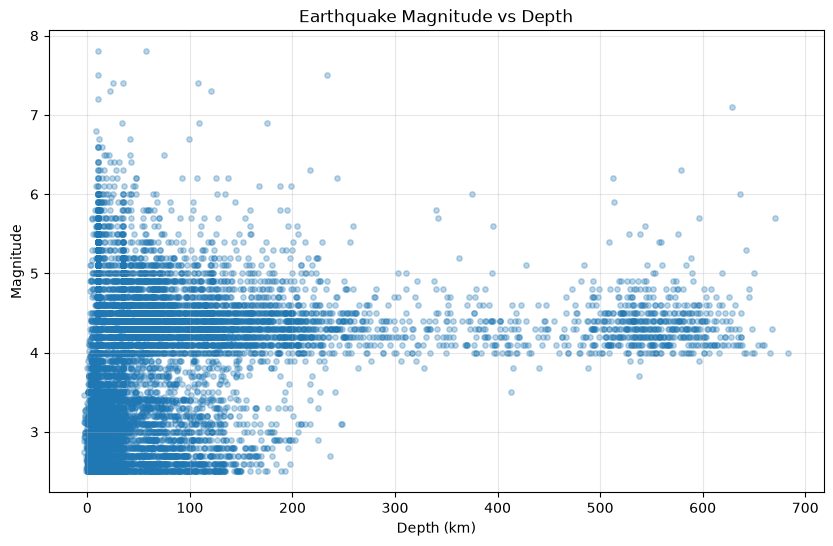

In [11]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["depth"],
    df["magnitude"],
    alpha=0.3,
    s=15
)

plt.title("Earthquake Magnitude vs Depth")
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")

plt.grid(alpha=0.3)
plt.show()

In [12]:
correlation = df["magnitude"].corr(df["depth"])

print(f"Correlation between magnitude and depth: {correlation:.4f}")

Correlation between magnitude and depth: 0.1810


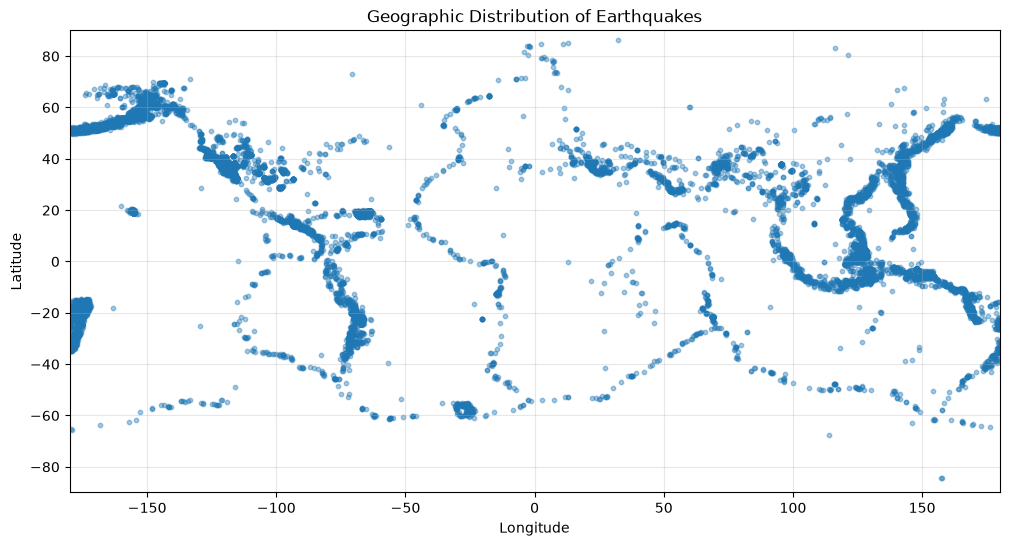

In [13]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df["longitude"],
    df["latitude"],
    s=10,
    alpha=0.4
)

plt.title("Geographic Distribution of Earthquakes")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.xlim(-180, 180)
plt.ylim(-90, 90)

plt.grid(alpha=0.3)
plt.show()

Earthquakes magnitude >= 5.0: 1,360
Percentage of dataset: 6.96%


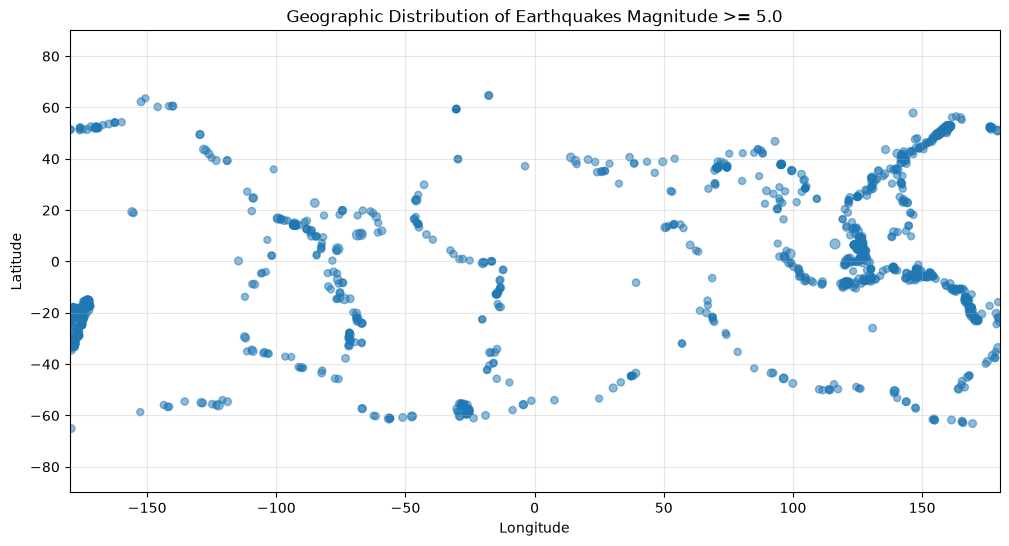

In [14]:
strong_events = df[df["magnitude"] >= 5.0]

print(f"Earthquakes magnitude >= 5.0: {len(strong_events):,}")
print(f"Percentage of dataset: {len(strong_events) / len(df) * 100:.2f}%")

plt.figure(figsize=(12, 6))

plt.scatter(
    strong_events["longitude"],
    strong_events["latitude"],
    s=strong_events["magnitude"] ** 2,
    alpha=0.5
)

plt.title("Geographic Distribution of Earthquakes Magnitude >= 5.0")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.xlim(-180, 180)
plt.ylim(-90, 90)

plt.grid(alpha=0.3)
plt.show()

Earthquakes by month:
month
1    2346
2    2109
3    2488
4    2595
5    2216
6    2490
7    2640
8    2390
9     253
dtype: int64


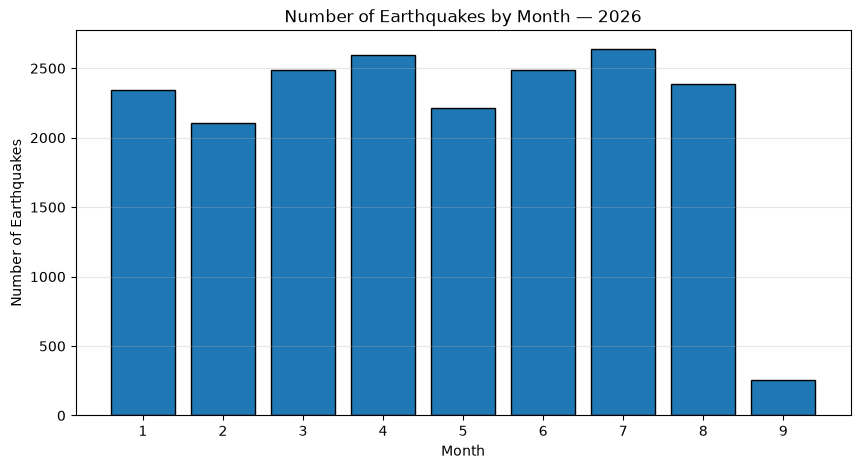

In [15]:
monthly_counts = df.groupby("month").size()

print("Earthquakes by month:")
print(monthly_counts)

plt.figure(figsize=(10, 5))

plt.bar(monthly_counts.index, monthly_counts.values, edgecolor="black")

plt.title("Number of Earthquakes by Month — 2026")
plt.xlabel("Month")
plt.ylabel("Number of Earthquakes")

plt.xticks(range(1, 10))
plt.grid(axis="y", alpha=0.3)

plt.show()

In [16]:
monthly_analysis = df.groupby("month").agg(
    total_earthquakes=("id", "count"),
    strong_earthquakes=("magnitude", lambda x: (x >= 5.0).sum())
)

monthly_analysis["strong_percentage"] = (
    monthly_analysis["strong_earthquakes"]
    / monthly_analysis["total_earthquakes"]
    * 100
)

print(monthly_analysis.round(2))

       total_earthquakes  strong_earthquakes  strong_percentage
month                                                          
1                   2346                 179               7.63
2                   2109                 113               5.36
3                   2488                 159               6.39
4                   2595                 169               6.51
5                   2216                 118               5.32
6                   2490                 180               7.23
7                   2640                 229               8.67
8                   2390                 187               7.82
9                    253                  26              10.28


Earthquakes by hour:
hour
0     823
1     819
2     833
3     762
4     777
5     826
6     859
7     812
8     917
9     805
10    855
11    807
12    811
13    807
14    800
15    854
16    789
17    815
18    771
19    769
20    770
21    808
22    845
23    793
dtype: int64


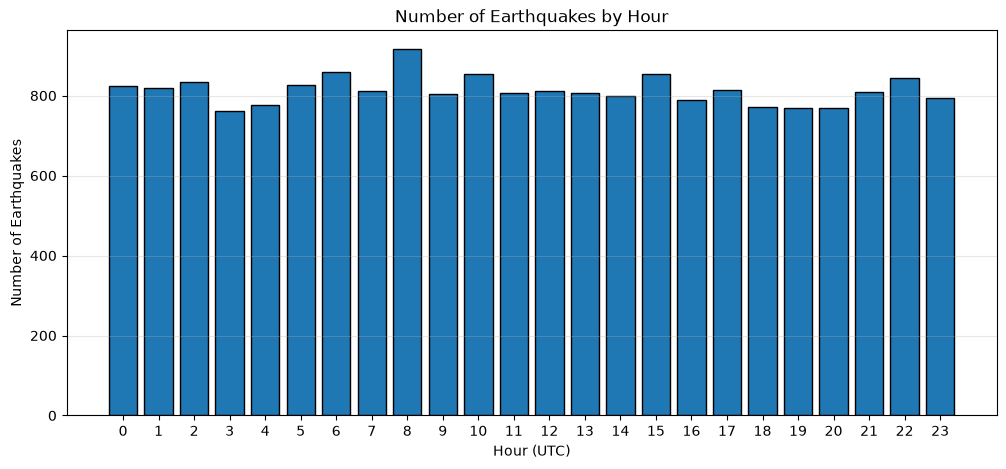

In [17]:
hourly_counts = df.groupby("hour").size()

print("Earthquakes by hour:")
print(hourly_counts)

plt.figure(figsize=(12, 5))

plt.bar(hourly_counts.index, hourly_counts.values, edgecolor="black")

plt.title("Number of Earthquakes by Hour")
plt.xlabel("Hour (UTC)")
plt.ylabel("Number of Earthquakes")

plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.show()

      total_earthquakes  strong_earthquakes  strong_percentage
hour                                                          
0                   823                  54               6.56
1                   819                  54               6.59
2                   833                  57               6.84
3                   762                  64               8.40
4                   777                  50               6.44
5                   826                  55               6.66
6                   859                  77               8.96
7                   812                  60               7.39
8                   917                  70               7.63
9                   805                  49               6.09
10                  855                  66               7.72
11                  807                  58               7.19
12                  811                  51               6.29
13                  807                  54            

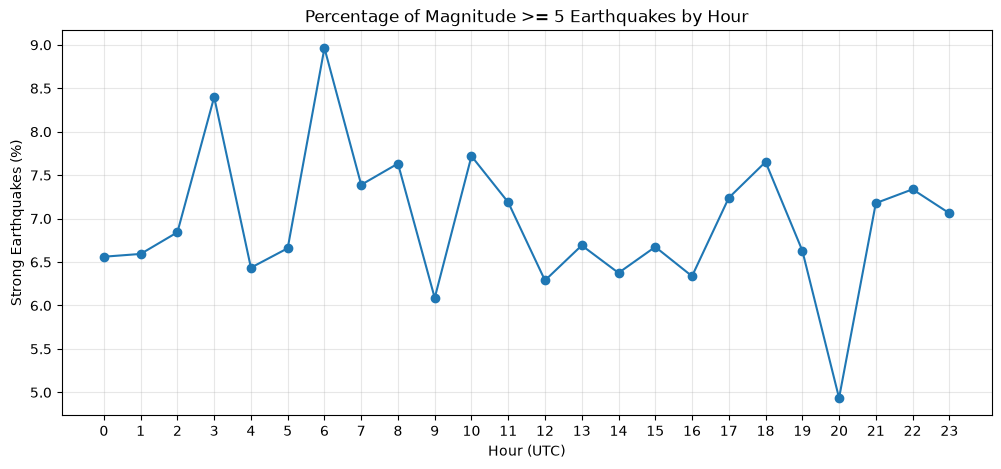

In [18]:
hourly_analysis = df.groupby("hour").agg(
    total_earthquakes=("id", "count"),
    strong_earthquakes=("magnitude", lambda x: (x >= 5.0).sum())
)

hourly_analysis["strong_percentage"] = (
    hourly_analysis["strong_earthquakes"]
    / hourly_analysis["total_earthquakes"]
    * 100
)

print(hourly_analysis.round(2))

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_analysis.index,
    hourly_analysis["strong_percentage"],
    marker="o"
)

plt.title("Percentage of Magnitude >= 5 Earthquakes by Hour")
plt.xlabel("Hour (UTC)")
plt.ylabel("Strong Earthquakes (%)")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()

In [19]:
numeric_columns = [
    "magnitude",
    "depth",
    "latitude",
    "longitude",
    "month",
    "day",
    "hour",
    "day_of_week",
    "is_shallow"
]

correlation_matrix = df[numeric_columns].corr()

print("Correlation matrix:")
display(correlation_matrix.round(3))

Correlation matrix:


,magnitude,depth,latitude,longitude,month,day,hour,day_of_week,is_shallow
magnitude,1.000,0.181,-0.623,0.553,0.014,0.007,0.017,-0.019,-0.153
depth,0.181,1.000,-0.297,-0.001,-0.028,-0.000,0.026,0.019,-0.705
latitude,-0.623,-0.297,1.000,-0.255,-0.022,-0.019,-0.012,0.001,0.220
longitude,0.553,-0.001,-0.255,1.000,0.041,-0.046,0.009,-0.029,-0.056
month,0.014,-0.028,-0.022,0.041,1.000,-0.041,0.018,0.010,0.028
day,0.007,-0.000,-0.019,-0.046,-0.041,1.000,0.003,-0.008,-0.003
hour,0.017,0.026,-0.012,0.009,0.018,0.003,1.000,0.015,-0.017
day_of_week,-0.019,0.019,0.001,-0.029,0.010,-0.008,0.015,1.000,-0.017
is_shallow,-0.153,-0.705,0.220,-0.056,0.028,-0.003,-0.017,-0.017,1.000


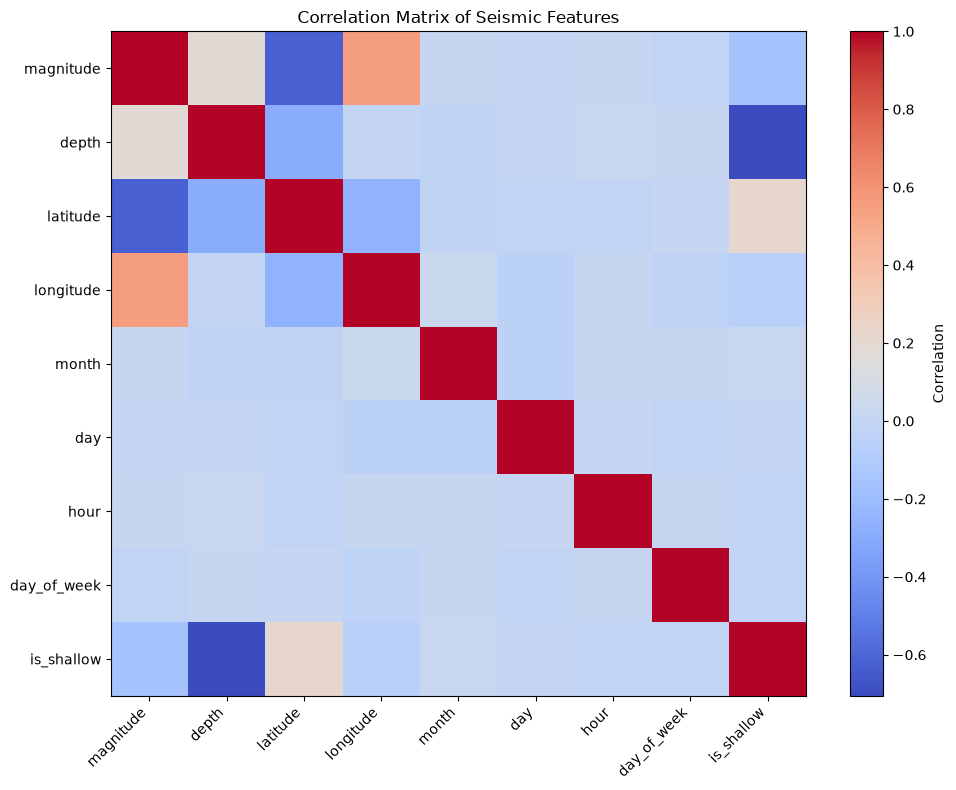

In [20]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title("Correlation Matrix of Seismic Features")

plt.tight_layout()
plt.show()

In [21]:
# Create classification target
# 1 = magnitude >= 5.0
# 0 = magnitude < 5.0

df["strong_earthquake"] = (df["magnitude"] >= 5.0).astype(int)

target_counts = df["strong_earthquake"].value_counts().sort_index()
target_percentages = (
    df["strong_earthquake"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Target distribution:")
print(target_counts)

print("\nTarget percentages:")
print(target_percentages.round(2))

Target distribution:
strong_earthquake
0    18167
1     1360
Name: count, dtype: int64

Target percentages:
strong_earthquake
0    93.04
1     6.96
Name: proportion, dtype: float64


In [22]:
features = [
    "latitude",
    "longitude",
    "depth",
    "month",
    "day",
    "hour",
    "day_of_week"
]

target = "strong_earthquake"

ml_df = df[features + [target]].copy()

print("ML dataset shape:")
print(ml_df.shape)

print("\nFeatures:")
for feature in features:
    print("-", feature)

print("\nTarget:")
print("-", target)

print("\nFirst 5 rows:")
display(ml_df.head())

ML dataset shape:
(19527, 8)

Features:
- latitude
- longitude
- depth
- month
- day
- hour
- day_of_week

Target:
- strong_earthquake

First 5 rows:


,latitude,longitude,depth,month,day,hour,day_of_week,strong_earthquake
0,59.7750,-152.8600,112.1000,9,3,23,3,0
1,52.0704,-169.2724,10.0000,9,3,23,3,0
2,31.6560,-104.3870,6.0999,9,3,23,3,0
3,52.0907,-169.2923,10.0000,9,3,22,3,0
4,52.1742,-169.2418,10.0000,9,3,22,3,0


In [23]:
OUTPUT_FILE = "data/usgs_ml_ready_2026.csv"

ml_df.to_csv(OUTPUT_FILE, index=False)

print("ML-ready dataset saved successfully.")
print(f"File: {OUTPUT_FILE}")
print(f"Rows: {len(ml_df):,}")
print(f"Columns: {len(ml_df.columns)}")

ML-ready dataset saved successfully.
File: data/usgs_ml_ready_2026.csv
Rows: 19,527
Columns: 8
